In [41]:
# Imports and Configuration
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import json
import warnings
warnings.filterwarnings('ignore')

# Configuration
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = [512, 256, 128]
DROPOUT_RATE = 0.3
NUM_CLASSES = 5
CLASS_NAMES = ['Sweet', 'Bitter', 'Umami', 'Sour', 'Undefined']

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Data Loading

In [42]:
# Load data
mol2vec_df = pd.read_csv('embeddings/mol2vec.csv')
chemberta_df = pd.read_csv('embeddings/chemberta.csv')

mol2vec_cols = [col for col in mol2vec_df.columns if col.startswith('mol2vec_')]
chemberta_cols = [col for col in chemberta_df.columns if col.startswith('chemberta_')]

mol2vec_features = mol2vec_df[mol2vec_cols].values
chemberta_features = chemberta_df[chemberta_cols].values

# Convert multi-hot labels to single class index via argmax
y_multihot = mol2vec_df[CLASS_NAMES].values
y = np.argmax(y_multihot, axis=1)  # shape [N]

print(f"Mol2Vec: {mol2vec_features.shape}, ChemBERTa: {chemberta_features.shape}")
print(f"Labels: {y.shape}, dtype: {y.dtype}, classes: {np.unique(y)}")
print(f"\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y == i).sum()
    print(f"  {name} ({i}): {count} ({count/len(y)*100:.1f}%)")

Mol2Vec: (12823, 300), ChemBERTa: (12823, 768)
Labels: (12823,), dtype: int64, classes: [0 1 2 3 4]

Class distribution:
  Sweet (0): 6473 (50.5%)
  Bitter (1): 2210 (17.2%)
  Umami (2): 220 (1.7%)
  Sour (3): 1522 (11.9%)
  Undefined (4): 2398 (18.7%)


In [43]:
# Combine embeddings
X = np.concatenate([mol2vec_features, chemberta_features], axis=1)
print(f"Combined features: {X.shape}")

Combined features: (12823, 1068)


In [44]:
# Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 8976, Val: 1923, Test: 1924


In [45]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Features standardized")

Features standardized


## 2. Class Weights

In [46]:
# Compute class weights for handling imbalanced classes
def compute_class_weights(y_train, num_classes):
    """Compute inverse-frequency class weights with sqrt smoothing."""
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    weights = np.sqrt(len(y_train) / (num_classes * counts))
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(y_train, NUM_CLASSES).to(device)
print(f"Class weights: {dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3)))}")

Class weights: {'Sweet': np.float32(0.629), 'Bitter': np.float32(1.077), 'Umami': np.float32(3.414), 'Sour': np.float32(1.298), 'Undefined': np.float32(1.034)}


## 3. Dataset & DataLoader

In [47]:
# Dataset and DataLoader
class MolecularTasteDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # class indices
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MolecularTasteDataset(X_train_scaled, y_train)
val_dataset = MolecularTasteDataset(X_val_scaled, y_val)
test_dataset = MolecularTasteDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
sample_X, sample_y = next(iter(train_loader))
print(f"DataLoaders created (batch_size={BATCH_SIZE})")
print(f"Sanity check — X: {sample_X.shape}, y: {sample_y.shape}, y.dtype: {sample_y.dtype}")
assert sample_y.dtype == torch.long, "Targets must be torch.long"
assert sample_y.ndim == 1, "Targets must be 1D class indices"

DataLoaders created (batch_size=32)
Sanity check — X: torch.Size([32, 1068]), y: torch.Size([32]), y.dtype: torch.int64


## 4. Model Architecture

In [48]:
# Multiclass Taste Classifier (single-head)
class TasteClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], num_classes=5, dropout_rate=0.3):
        super().__init__()
        
        # Shared MLP backbone
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
        self.backbone = nn.Sequential(*layers)
        
        # Single classification head
        self.classifier = nn.Linear(hidden_dims[-1], num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)  # [B, num_classes]
        return logits

INPUT_DIM = X_train_scaled.shape[1]
model = TasteClassifier(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, DROPOUT_RATE).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Output shape check: {model(torch.randn(2, INPUT_DIM).to(device)).shape}")  # [2, 5]

Model parameters: 713,989
Output shape check: torch.Size([2, 5])


## 5. Loss & Optimizer

In [49]:
# CrossEntropyLoss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(f"Loss: CrossEntropyLoss (weighted), Optimizer: AdamW")

Loss: CrossEntropyLoss (weighted), Optimizer: AdamW



## 6. Evaluation Metrics

In [50]:
# Evaluation metrics
def compute_metrics(y_true, y_pred, class_names):
    """Compute multiclass evaluation metrics."""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    # Per-class F1
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    for i, name in enumerate(class_names):
        metrics[f'{name}_F1'] = per_class_f1[i] if i < len(per_class_f1) else 0.0
    return metrics

def evaluate_model(model, dataloader, criterion, device, class_names):
    """Evaluate model on a dataset."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            
            # Sanity checks
            assert logits.shape[1] == NUM_CLASSES, f"Logits shape {logits.shape} != [B, {NUM_CLASSES}]"
            assert y_batch.dtype == torch.long, f"Targets dtype {y_batch.dtype} != torch.long"
            assert y_batch.ndim == 1, f"Targets shape {y_batch.shape} is not 1D"
            
            total_loss += criterion(logits, y_batch).item() * y_batch.size(0)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_labels.append(y_batch.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.vstack(all_probs)
    
    metrics = compute_metrics(y_true, y_pred, class_names)
    metrics['loss'] = total_loss / len(dataloader.dataset)
    return metrics, y_true, y_pred, y_prob

print("Evaluation functions defined")

Evaluation functions defined


## 7. Training

In [51]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                device, class_names, num_epochs=100, patience=15, verbose=True):
    """Train model with early stopping based on validation macro F1."""
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'val_macro_f1': []}
    
    best_f1, best_state, no_improve = 0.0, None, 0
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch.long())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * y_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # Evaluate
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, device, class_names)
        scheduler.step(val_metrics['loss'])
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        
        # Early stopping on macro F1
        if val_metrics['macro_f1'] > best_f1:
            best_f1 = val_metrics['macro_f1']
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            marker = ' *'
        else:
            no_improve += 1
            marker = ''
        
        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"Epoch {epoch+1:3d} | Loss: {train_loss:.4f}/{val_metrics['loss']:.4f} | "
                  f"Acc: {val_metrics['accuracy']:.4f} | F1: {val_metrics['macro_f1']:.4f}{marker}")
        
        if no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_state:
        model.load_state_dict(best_state)
    return history, best_f1

print("Training function defined")

Training function defined


In [52]:
# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    
    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss')
    
    axes[1].plot(epochs, history['val_accuracy'])
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Validation Accuracy')
    axes[1].set_ylim([0, 1])
    
    axes[2].plot(epochs, history['val_macro_f1'])
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro F1'); axes[2].set_title('Validation Macro F1')
    axes[2].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

print("Plotting function defined")

Plotting function defined


## 8. Train Model

Training model...

Epoch   1 | Loss: 0.8456/0.6639 | Acc: 0.7639 | F1: 0.7052 *
Epoch   1 | Loss: 0.8456/0.6639 | Acc: 0.7639 | F1: 0.7052 *
Epoch  10 | Loss: 0.4355/0.5405 | Acc: 0.8138 | F1: 0.7795
Epoch  10 | Loss: 0.4355/0.5405 | Acc: 0.8138 | F1: 0.7795
Epoch  20 | Loss: 0.2855/0.6050 | Acc: 0.8196 | F1: 0.7962
Epoch  20 | Loss: 0.2855/0.6050 | Acc: 0.8196 | F1: 0.7962
Epoch  30 | Loss: 0.2172/0.6946 | Acc: 0.8227 | F1: 0.8067
Epoch  30 | Loss: 0.2172/0.6946 | Acc: 0.8227 | F1: 0.8067
Early stopping at epoch 32

Best validation Macro F1: 0.8126
Early stopping at epoch 32

Best validation Macro F1: 0.8126


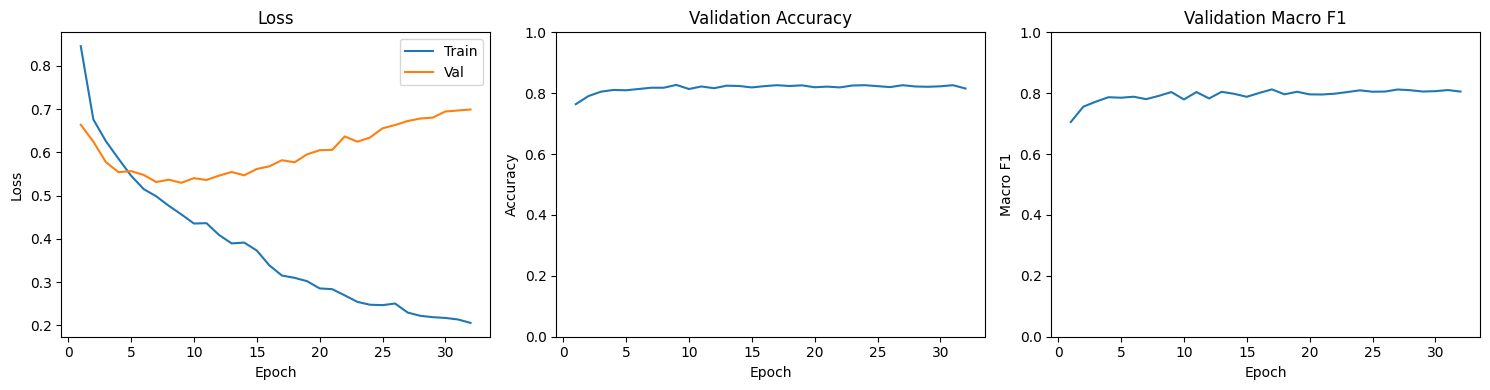

In [53]:
# Train model
print("Training model...")
history, best_f1 = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                                device, CLASS_NAMES, num_epochs=100, patience=15)
print(f"\nBest validation Macro F1: {best_f1:.4f}")
plot_training_history(history)

## 9. Test Evaluation

In [54]:
# Test set evaluation
test_metrics, y_true_test, y_pred_test, y_prob_test = evaluate_model(model, test_loader, criterion, device, CLASS_NAMES)

print(f"Test Results:")
print(f"  Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"  Macro F1:    {test_metrics['macro_f1']:.4f}")
print(f"  Weighted F1: {test_metrics['weighted_f1']:.4f}")
print(f"\nPer-class F1:")
for name in CLASS_NAMES:
    print(f"  {name}: {test_metrics[f'{name}_F1']:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))

Test Results:
  Accuracy:    0.8082
  Macro F1:    0.7741
  Weighted F1: 0.8130

Per-class F1:
  Sweet: 0.8834
  Bitter: 0.7316
  Umami: 0.7059
  Sour: 0.8912
  Undefined: 0.6583

Classification Report:
              precision    recall  f1-score   support

       Sweet       0.94      0.84      0.88       971
      Bitter       0.73      0.73      0.73       332
       Umami       0.69      0.73      0.71        33
        Sour       0.85      0.93      0.89       228
   Undefined       0.60      0.73      0.66       360

    accuracy                           0.81      1924
   macro avg       0.76      0.79      0.77      1924
weighted avg       0.82      0.81      0.81      1924



In [55]:
# Test set class distribution
print("Test set class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_test == i).sum()
    pred_count = (y_pred_test == i).sum()
    print(f"  {name}: {count} actual, {pred_count} predicted")

Test set class distribution:
  Sweet: 971 actual, 865 predicted
  Bitter: 332 actual, 335 predicted
  Umami: 33 actual, 35 predicted
  Sour: 228 actual, 250 predicted
  Undefined: 360 actual, 439 predicted


## 10. Confusion Matrices

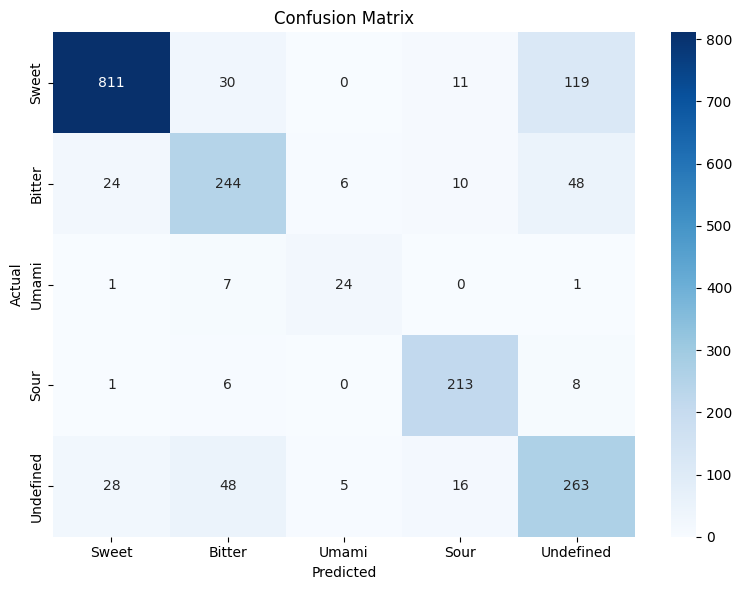

In [56]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 11. Per-Class Confidence Distribution

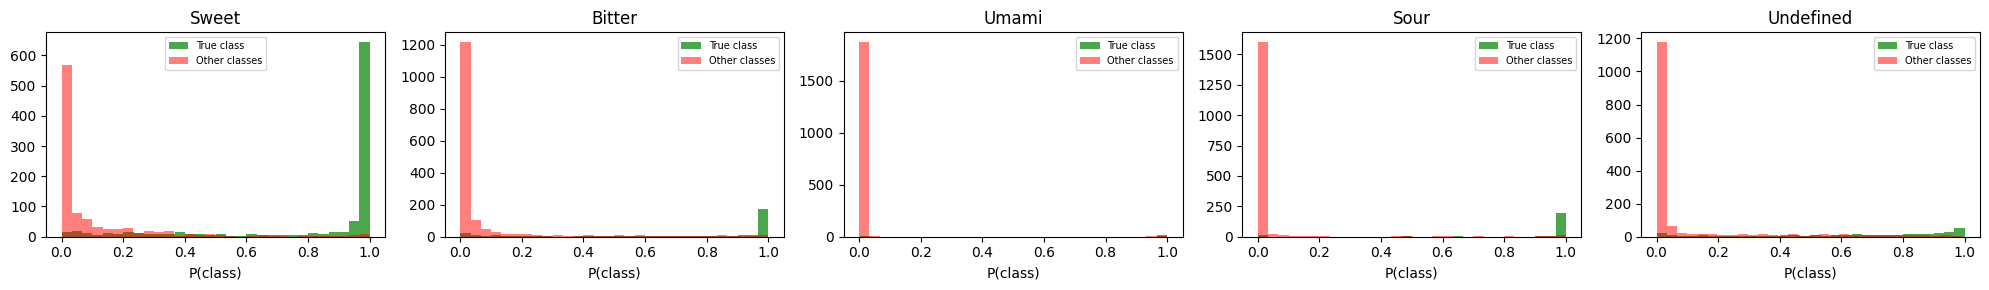

In [57]:
# Per-class predicted probability distributions
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 3))
for i, name in enumerate(CLASS_NAMES):
    mask_correct = y_true_test == i
    mask_wrong = y_true_test != i
    if mask_correct.sum() > 0:
        axes[i].hist(y_prob_test[mask_correct, i], bins=30, alpha=0.7, label='True class', color='green')
    if mask_wrong.sum() > 0:
        axes[i].hist(y_prob_test[mask_wrong, i], bins=30, alpha=0.5, label='Other classes', color='red')
    axes[i].set_title(name); axes[i].set_xlabel('P(class)'); axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 12. Save Model

In [58]:
# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'config': {
        'input_dim': INPUT_DIM, 
        'hidden_dims': HIDDEN_DIMS, 
        'num_classes': NUM_CLASSES, 
        'dropout_rate': DROPOUT_RATE
    }
}, 'taste_classifier_model.pth')

with open('taste_mapping.json', 'w') as f:
    json.dump({'classes': CLASS_NAMES}, f)
print("Model saved")

Model saved


## 13. Inference

In [59]:
# Inference function
def predict_taste(mol2vec_feat, chemberta_feat, model, scaler, device):
    """Predict taste class from molecular embeddings."""
    X = np.concatenate([mol2vec_feat.reshape(1, -1), chemberta_feat.reshape(1, -1)], axis=1)
    X_scaled = scaler.transform(X)
    
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_scaled, dtype=torch.float32).to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    predicted_class = int(np.argmax(probs))
    return {
        'predicted_class': CLASS_NAMES[predicted_class],
        'confidence': float(probs[predicted_class]),
        'probabilities': {name: float(probs[i]) for i, name in enumerate(CLASS_NAMES)}
    }

# Test inference
sample_result = predict_taste(mol2vec_features[0], chemberta_features[0], model, scaler, device)
print("Sample prediction:", json.dumps(sample_result, indent=2))

Sample prediction: {
  "predicted_class": "Undefined",
  "confidence": 0.5782631635665894,
  "probabilities": {
    "Sweet": 0.13970215618610382,
    "Bitter": 0.2652933895587921,
    "Umami": 0.00025381825980730355,
    "Sour": 0.01648746244609356,
    "Undefined": 0.5782631635665894
  }
}


## 14. Model Summary

In [60]:
# Model summary
mol2vec_dim = len(mol2vec_cols)
chemberta_dim = len(chemberta_cols)
print(f"Model Summary:")
print(f"  Task: Single-label multiclass classification")
print(f"  Input: {INPUT_DIM}d (Mol2Vec {mol2vec_dim}d + ChemBERTa {chemberta_dim}d)")
print(f"  Hidden: {HIDDEN_DIMS}")
print(f"  Output: {NUM_CLASSES} classes ({', '.join(CLASS_NAMES)})")
print(f"  Loss: CrossEntropyLoss (weighted)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Summary:
  Task: Single-label multiclass classification
  Input: 1068d (Mol2Vec 300d + ChemBERTa 768d)
  Hidden: [512, 256, 128]
  Output: 5 classes (Sweet, Bitter, Umami, Sour, Undefined)
  Loss: CrossEntropyLoss (weighted)
  Parameters: 713,989
